# Segmentación de Zonas de Alta Incidencia Delictiva con K-Means

**Autor**: Juan Diego Argüello Nájera  
**Herramientas**: Python · pandas · scikit-learn · Plotly · Folium · geopy  
**Dataset**: ENVIPE (Encuesta Nacional de Victimización y Percepción sobre Seguridad Pública) — INEGI  

---

## Objetivo

Aplicar clustering no supervisado para identificar grupos de entidades federativas
con patrones de victimización similares, apoyando la priorización diferenciada de
recursos de seguridad pública.

## Pregunta central

¿Existen grupos naturales de estados con comportamiento delictivo homogéneo
que no sean evidentes a simple vista?

## Estructura del notebook

1. Importación de librerías  
2. Carga y exploración del dataset  
3. Limpieza de datos (valores nulos, columnas irrelevantes)  
4. Análisis de correlación y pairplot  
5. Normalización con MinMaxScaler  
6. Reducción de dimensionalidad con PCA  
7. Aplicación de K-Means (selección de K con método del codo)  
8. Visualización de clusters en espacio PCA  
9. Mapa interactivo con Folium  

---
> **Fuente de datos**: [ENVIPE — INEGI](https://www.inegi.org.mx/programas/envipe/)  
> Los datos usados en este análisis corresponden a la encuesta de percepción de seguridad pública.  

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
import plotly.graph_objects as go
import numpy as np

import folium
from geopy.geocoders import Nominatim
from folium import plugins
import time
import random

In [ ]:
import os
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")

df = pd.read_csv(os.path.join(DATA_DIR, "TMod_Vic_Columnas_filtradas.csv"))
print(df.head())

In [ ]:
# Cargar el archivo CSV en un DataFrame
df = pd.read_csv('/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos en Mexico/TMod_Vic_Columnas_filtradas.csv')

# Mostrar las primeras filas del DataFrame para ver qué contiene
print(df.head())

   BPCOD  BP1_1  BP1_2C  BP1_3C  BP1_4  BP1_5  BP1_9  BP1_11   BP1_34
0      7      1       1       1      3      1    NaN     NaN  10000.0
1      2      9       1       1      4      1    NaN     NaN  20000.0
2      7      6       1       1      2      5    NaN     NaN    150.0
3      5     11       1       1      2      1    1.0     9.0   3000.0
4      3     10       1       1      3      2    NaN     NaN   1500.0


In [ ]:
# Obtener el tamaño del DataFrame (número de filas y columnas)
tamaño_df = df.shape
# Mostrar el tamaño
print(f"El DataFrame tiene {tamaño_df[0]} filas y {tamaño_df[1]} columnas.")

El DataFrame tiene 37614 filas y 9 columnas.


In [ ]:
# Revisar cuántas celdas están vacías en cada columna
missing_values = df.isnull().sum()

# Mostrar el número de celdas vacías por columna
print("Número de celdas vacías por columna:")
print(missing_values)

Número de celdas vacías por columna:
BPCOD         0
BP1_1         0
BP1_2C        0
BP1_3C        0
BP1_4         0
BP1_5         0
BP1_9     23569
BP1_11    23569
BP1_34     5882
dtype: int64


In [ ]:
# Eliminar las filas donde la columna BP1_34 tenga valores nulos (NaN)
df_filtrado = df.dropna(subset=['BP1_34'])

# Eliminar las columnas BP1_9 y BP1_11
df_filtrado = df_filtrado.drop(columns=['BP1_9', 'BP1_11'])
df_filtrado.head()

# Mostrar el número de filas y columnas después de eliminar las filas nulas
print(f"El DataFrame tiene {df_filtrado.shape[0]} filas y {df_filtrado.shape[1]} columnas después de eliminar los renglones con valores nulos en BP1_34.")


El DataFrame tiene 31732 filas y 7 columnas después de eliminar los renglones con valores nulos en BP1_34.


In [ ]:
# Revisar cuántas celdas están vacías en cada columna
missing_values = df_filtrado.isnull().sum()

# Mostrar el número de celdas vacías por columna
print("Número de celdas vacías por columna:")
print(missing_values)

Número de celdas vacías por columna:
BPCOD     0
BP1_1     0
BP1_2C    0
BP1_3C    0
BP1_4     0
BP1_5     0
BP1_34    0
dtype: int64


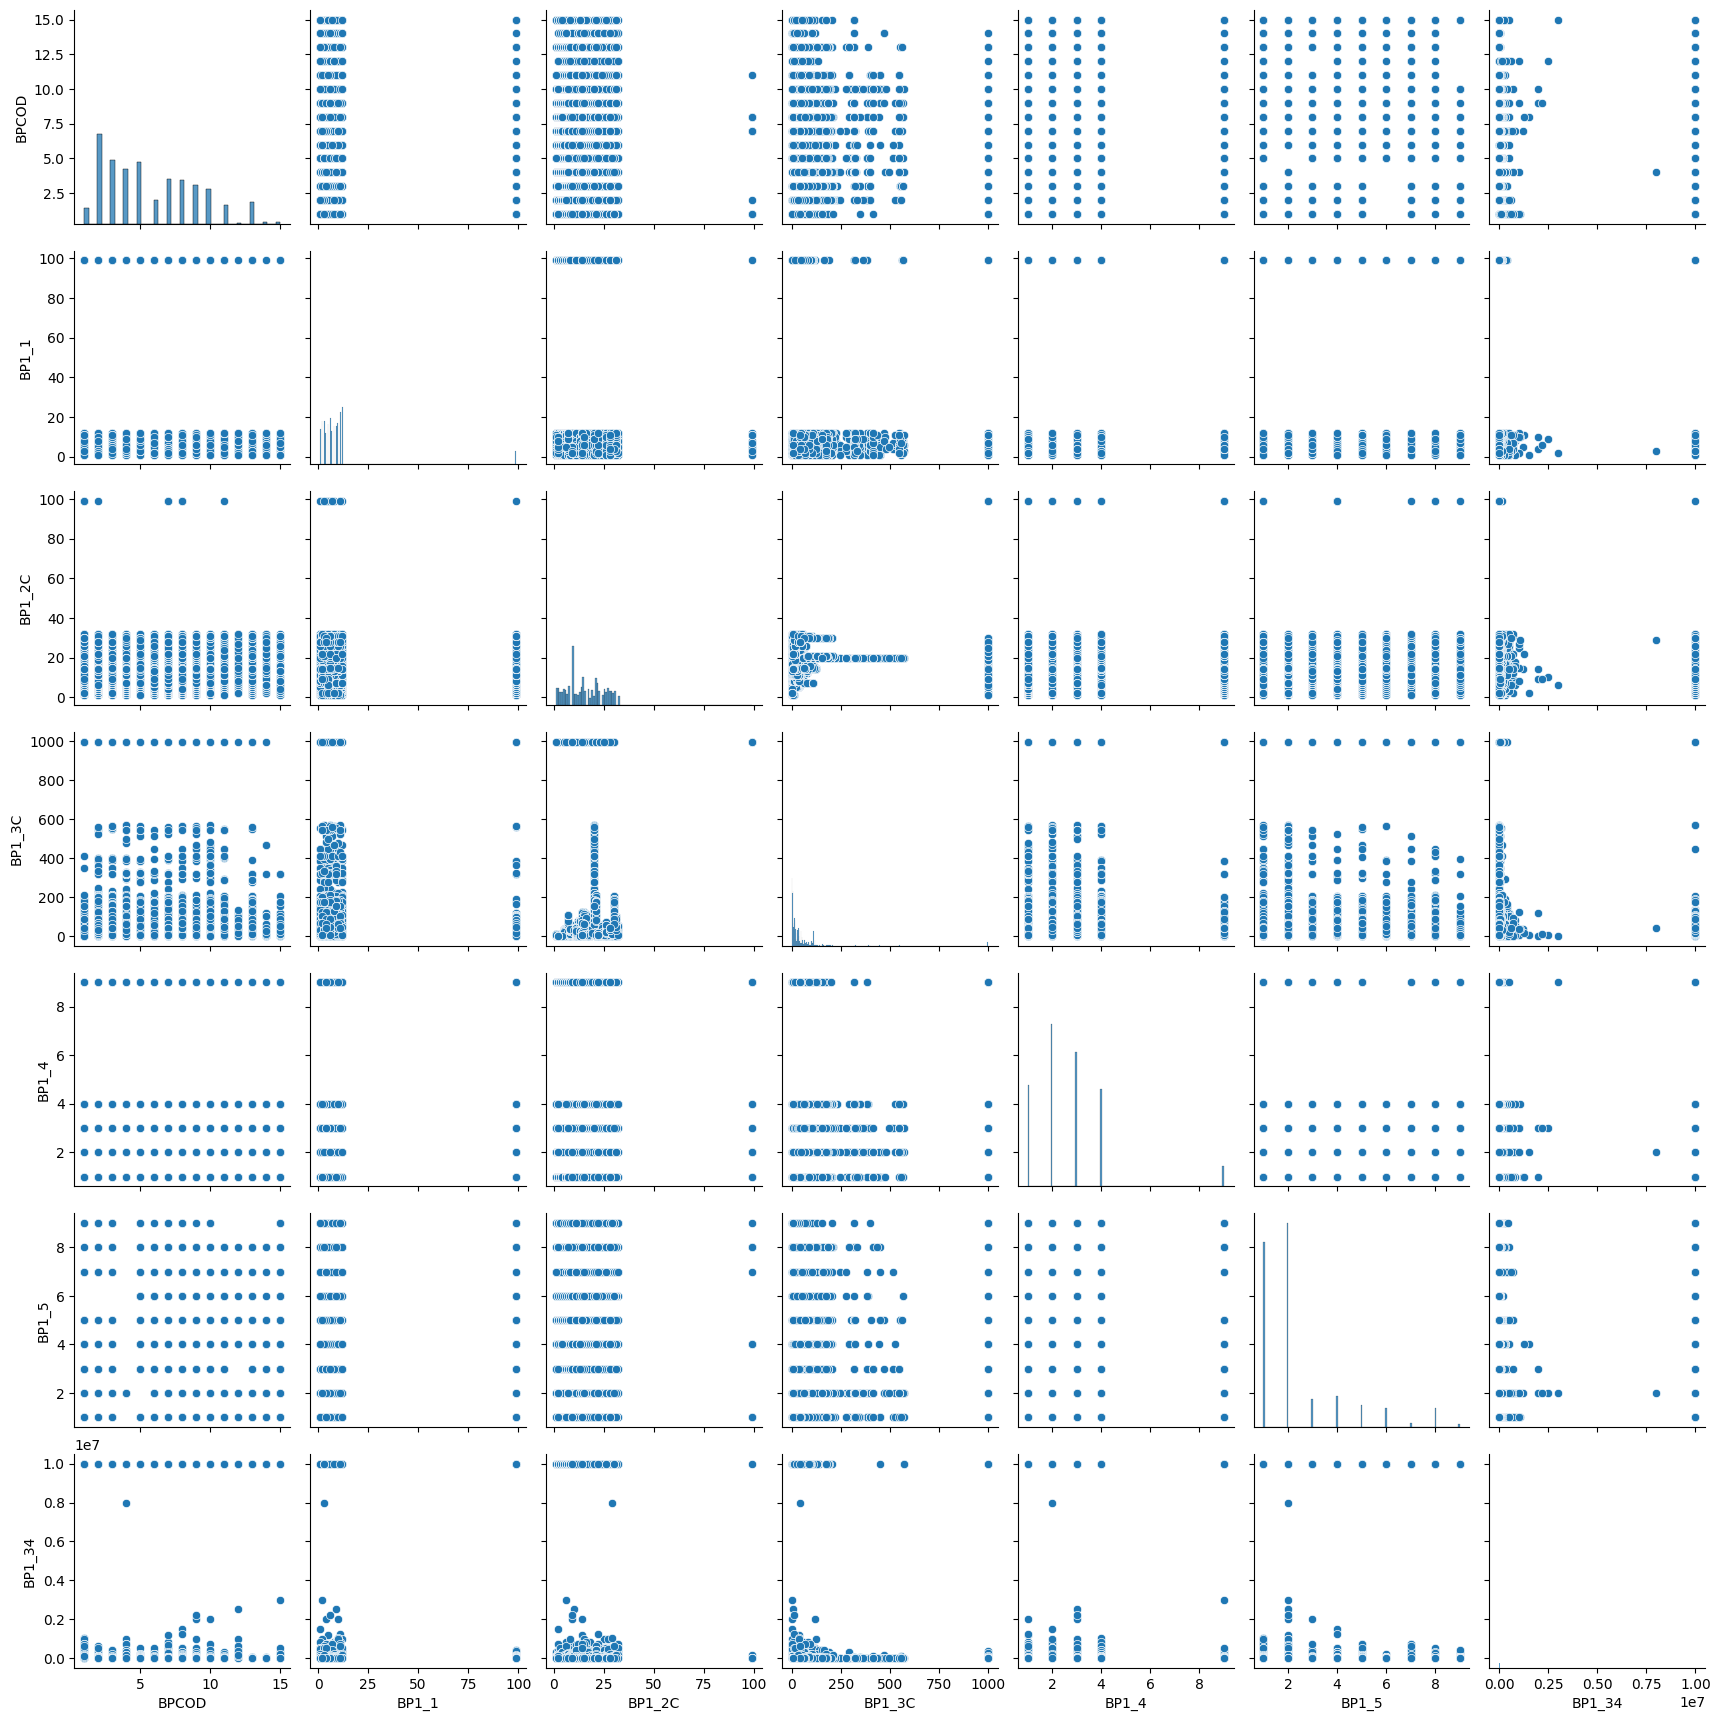

In [ ]:
# Seleccionar las columnas relevantes para el gráfico
columnas_seleccionadas = ['BPCOD', 'BP1_1', 'BP1_2C', 'BP1_3C', 'BP1_4', 'BP1_5', 'BP1_34']

# Crear un sub-DataFrame con solo esas columnas
df_seleccionado = df_filtrado[columnas_seleccionadas]

# Crear el gráfico de dispersión por pares (pairplot)
sns.pairplot(df_seleccionado)

# Mostrar el gráfico
plt.show()


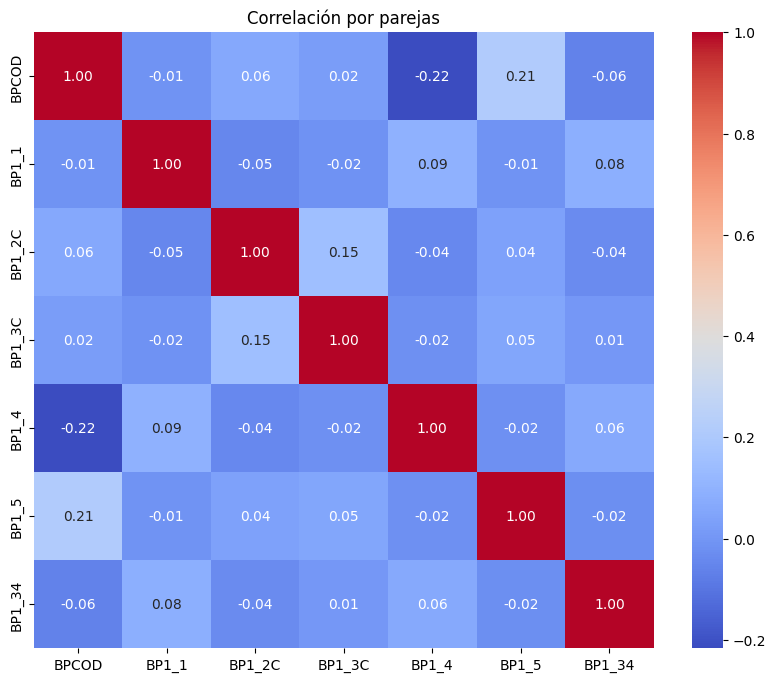

In [ ]:
numeric_columns = df_filtrado.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_columns.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación por parejas')
plt.show()

# Selección de columnas a emplear
Vamos a quitar las columnas relacionadas con estado y municipio en el cual se reportó el delito.

Se incluirán en un análisis posterior.

In [ ]:
# Crear un nuevo DataFrame sin las columnas BP1_2C y BP1_3C
df_sin_ubicaciones = df_filtrado.drop(columns=['BP1_2C', 'BP1_3C'])
#'BPCOD', 'BP1_4'

df_sin_ubicaciones.head()

,BPCOD,BP1_1,BP1_4,BP1_5,BP1_34
0,7,1,3,1,10000.0
1,2,9,4,1,20000.0
2,7,6,2,5,150.0
3,5,11,2,1,3000.0
4,3,10,3,2,1500.0


In [ ]:
# Obtener el número total de registros (filas) en el DataFrame
total_registros = df_sin_ubicaciones.shape[0]

# Mostrar el número total de registros
print(f"El DataFrame tiene {total_registros} registros.")

# Contar los valores NaN en cada columna del DataFrame
valores_na = df_sin_ubicaciones.isna().sum()

# Mostrar la cantidad de valores nulos por columna
print(valores_na)


El DataFrame tiene 31732 registros.
BPCOD     0
BP1_1     0
BP1_4     0
BP1_5     0
BP1_34    0
dtype: int64


## Normalización de los datos

Usamos el **MinMaxScaler** de `sklearn` para normalizar las columnas de ventas, lo que asegura que todas las variables tengan el mismo rango, facilitando su uso en técnicas como PCA o clustering.


In [ ]:
# Normalizar los datos con MinMaxScaler
scaler = MinMaxScaler()
df_normalizado = scaler.fit_transform(df_sin_ubicaciones)

# Convertir el resultado a un DataFrame para tener las columnas
df_normalizado = pd.DataFrame(df_normalizado, columns=df_sin_ubicaciones.columns)
df_normalizado.head()

,BPCOD,BP1_1,BP1_4,BP1_5,BP1_34
0,0.428571,0.000000,0.250,0.000,0.001000
1,0.071429,0.081633,0.375,0.000,0.002000
2,0.428571,0.051020,0.125,0.500,0.000015
3,0.285714,0.102041,0.125,0.000,0.000300
4,0.142857,0.091837,0.250,0.125,0.000150


## Análisis mediante PCA (Análisis de Componentes Principales)

Aplicamos PCA para reducir la dimensionalidad de los datos de ventas. Seleccionamos 2 componentes principales y visualizamos el resultado en un diagrama de dispersión.


In [ ]:
# Aplicar PCA para reducir las dimensiones a 2
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_normalizado)

# Convertir los resultados a un DataFrame para facilitar la visualización
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

df_pca.head()

,PC1,PC2
0,-0.029991,-0.152487
1,-0.347179,0.025685
2,0.279979,0.166502
3,-0.103121,-0.171316
4,-0.184510,0.033105


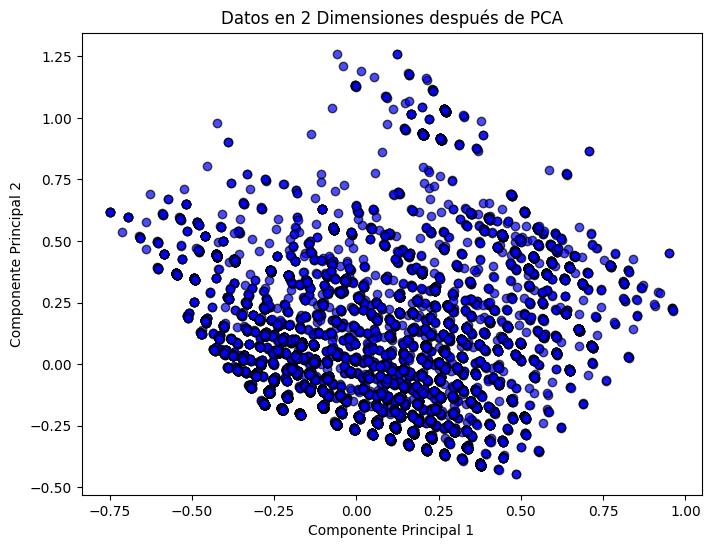

Varianza explicada por el componente 1: 0.33
Varianza explicada por el componente 2: 0.22


In [ ]:
# Visualizar los datos en un gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c='blue', edgecolor='k', alpha=0.7)
plt.title('Datos en 2 Dimensiones después de PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Mostrar las varianzas explicadas por cada componente
print(f"Varianza explicada por el componente 1: {pca.explained_variance_ratio_[0]:.2f}")
print(f"Varianza explicada por el componente 2: {pca.explained_variance_ratio_[1]:.2f}")

## Clustering con K-Means

Aplicamos el algoritmo **K-Means** para dividir los datos en 4 clusters, utilizando las componentes principales obtenidas con PCA. Luego visualizamos los clusters en un gráfico de dispersión.

Después de aplicar el método del codo, determinamos que el número óptimo de clusters es 3, por lo que aplicamos el modelo K-Means con 3 clusters y mostramos los resultados.


In [ ]:
# Aplicar K-means para crear 4 clusters
kmeans = KMeans(n_clusters=4, random_state=1)
df_pca['Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])

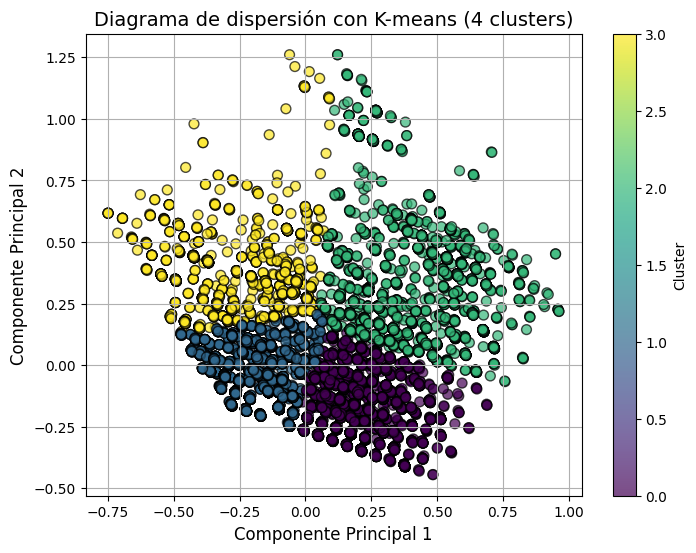

In [ ]:
# Paso 2: Graficar los resultados de los clusters
plt.figure(figsize=(8, 6))

# Usamos colores diferentes para cada cluster
plt.scatter(df_pca['PC1'],
            df_pca['PC2'],
            c=df_pca['Cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=50)

# Título y etiquetas
plt.title('Diagrama de dispersión con K-means (4 clusters)', fontsize=14)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)

# Agregar una leyenda para los clusters
plt.colorbar(label='Cluster')

# Mostrar el gráfico
plt.grid(True)
plt.show()

##Aplcamos el método del codo

In [ ]:
# Calcular la inercia para diferentes valores de k (de 1 a 10 clusters)
inercia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=30, random_state=1)
    kmeans.fit(df_pca[['PC1', 'PC2']])
    inercia.append(kmeans.inertia_)

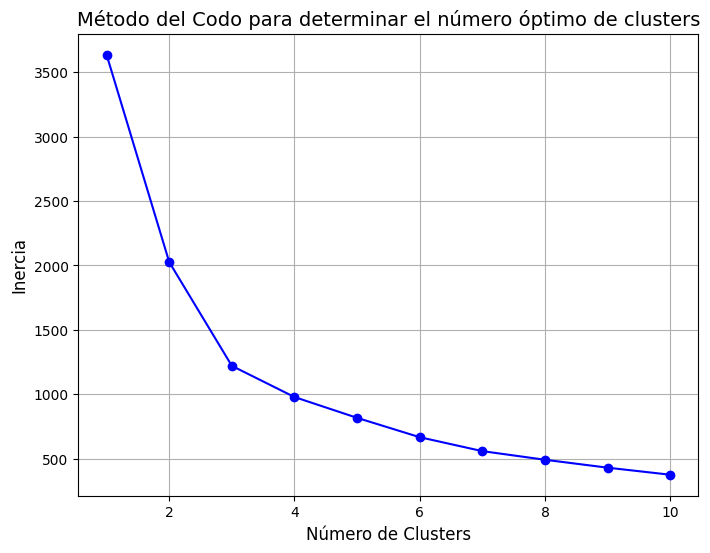

In [ ]:
# Paso 2: Graficar la inercia en función de k
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inercia, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para determinar el número óptimo de clusters', fontsize=14)
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.grid(True)
plt.show()

## Nos quedaremos con 3 clusters

In [ ]:
# Aplicar K-means para crear 3 clusters
kmeans = KMeans(n_clusters=3, n_init=1000, random_state=1)
df_pca['Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])

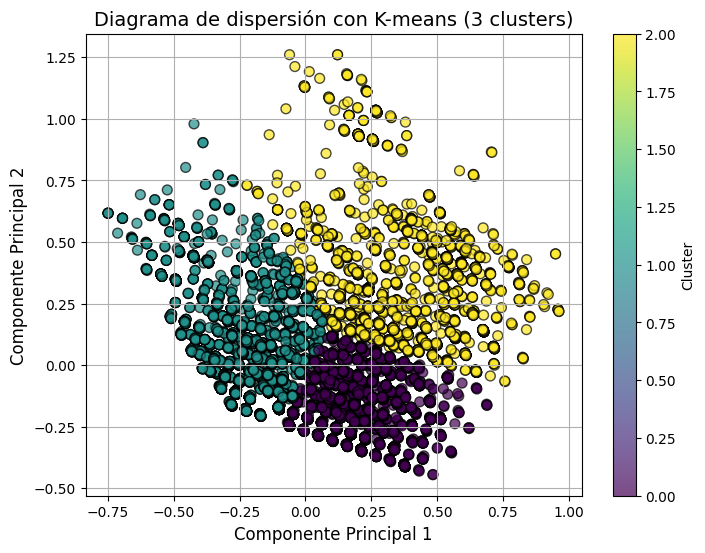

In [ ]:
# Paso 2: Graficar los resultados de los clusters
plt.figure(figsize=(8, 6))

# Usamos colores diferentes para cada cluster
plt.scatter(df_pca['PC1'],
            df_pca['PC2'],
            c=df_pca['Cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=50)

# Título y etiquetas
plt.title('Diagrama de dispersión con K-means (3 clusters)', fontsize=14)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)

# Agregar una leyenda para los clusters
plt.colorbar(label='Cluster')

# Mostrar el gráfico
plt.grid(True)
plt.show()

## Análisis de los clusters

En esta sección, agrupamos los datos por cluster y visualizamos las estadísticas descriptivas de las ventas en cada uno de los clusters. Utilizamos gráficos de cajas para comparar la distribución de las ventas entre los clusters.


In [ ]:
# Contar cuántas muestras hay en cada cluster
cluster_counts = df_pca['Cluster'].value_counts()

# Mostrar la información
print("Número de muestras por cluster:")
print(cluster_counts)

Número de muestras por cluster:
Cluster
1    16624
0    10874
2     4234
Name: count, dtype: int64


Observen el ínndice final de los dos dataframe siguientes, eso será un problema al querer unirlos.

Usaremos $reset\_intex$ para corregirlo.

In [ ]:
df_pca

,PC1,PC2,Cluster
0,-0.029991,-0.152487,0
1,-0.347179,0.025685,1
2,0.279979,0.166502,2
3,-0.103121,-0.171316,1
4,-0.184510,0.033105,1
...,...,...,...
31727,-0.224696,0.101560,1
31728,-0.185018,0.034134,1
31729,-0.127423,0.007368,1
31730,-0.491256,0.342884,1


In [ ]:
df_filtrado

,BPCOD,BP1_1,BP1_2C,BP1_3C,BP1_4,BP1_5,BP1_34
0,7,1,1,1,3,1,10000.0
1,2,9,1,1,4,1,20000.0
2,7,6,1,1,2,5,150.0
3,5,11,1,1,2,1,3000.0
4,3,10,1,1,3,2,1500.0
...,...,...,...,...,...,...,...
37608,3,10,15,62,4,2,500.0
37609,3,11,28,41,3,2,12000.0
37611,4,4,30,62,3,2,2000.0
37612,3,4,28,41,9,1,1500.0


In [ ]:
print(df_filtrado.shape)
print(df_pca.shape)

(31732, 7)
(31732, 3)


In [ ]:
# Crea un nuevo DataFrame que contenga las columnas necesarias
data_clustered = df_filtrado.copy()  # Crear una copia de 'data' para no modificar el original

# Asegúrate de que los índices sean los mismos
data_clustered = data_clustered.reset_index(drop=True)

# Asegúrate de que la columna de clusters esté presente en 'data_clustered'
data_clustered['Cluster'] = df_pca['Cluster']  # Añadir la columna de clusters

data_clustered.head()

,BPCOD,BP1_1,BP1_2C,BP1_3C,BP1_4,BP1_5,BP1_34,Cluster
0,7,1,1,1,3,1,10000.0,0
1,2,9,1,1,4,1,20000.0,1
2,7,6,1,1,2,5,150.0,2
3,5,11,1,1,2,1,3000.0,1
4,3,10,1,1,3,2,1500.0,1


In [ ]:
# Revisar cuántas celdas están vacías en cada columna
missing_values = data_clustered.isnull().sum()

# Mostrar el número de celdas vacías por columna
print("Número de celdas vacías por columna:")
print(missing_values)

Número de celdas vacías por columna:
BPCOD      0
BP1_1      0
BP1_2C     0
BP1_3C     0
BP1_4      0
BP1_5      0
BP1_34     0
Cluster    0
dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

# Calcular el índice de silueta para el clustering con 3 clusters
silhouette_avg = silhouette_score(df_pca[['PC1', 'PC2']], df_pca['Cluster'])
print(f"Índice de Silueta para el clustering con 3 clusters: {silhouette_avg:.2f}")


Índice de Silueta para el clustering con 3 clusters: 0.49


# Clave por columnas

* BPCOD: CÓDIGOS PARA DELITOS; del 1 al 15
* BP1_1: En qué mes del 2023 sucedió el (DELITO)
* BP1_2C: En qué Estado sucedió el (DELITO)?
* BP1_3C: ¿En qué Municipio/Alcaldía (CDMX) sucedió el (DELITO)?
* BP1_4: ¿Aproximadamente a qué hora se cometió el (DELITO)?
* BP1_5: En qué lugar sucedió el (DELITO): calle, casa, trabajo, etc
* BP1_9: Cuántos(as) delincuentes participaron en el (DELITO)
* BP1_11: Aproximadamente, ¿cuál era la edad del (de los) delincuente(s)?
* BP1_34: ¿En cuánto estima las pérdidas económicas a consecuencia del delito?


In [ ]:
data_clustered.head()

,BPCOD,BP1_1,BP1_2C,BP1_3C,BP1_4,BP1_5,BP1_34,Cluster
0,7,1,1,1,3,1,10000.0,0
1,2,9,1,1,4,1,20000.0,1
2,7,6,1,1,2,5,150.0,2
3,5,11,1,1,2,1,3000.0,1
4,3,10,1,1,3,2,1500.0,1


# BPCOD: CÓDIGOS PARA DELITOS; del 1 al 15

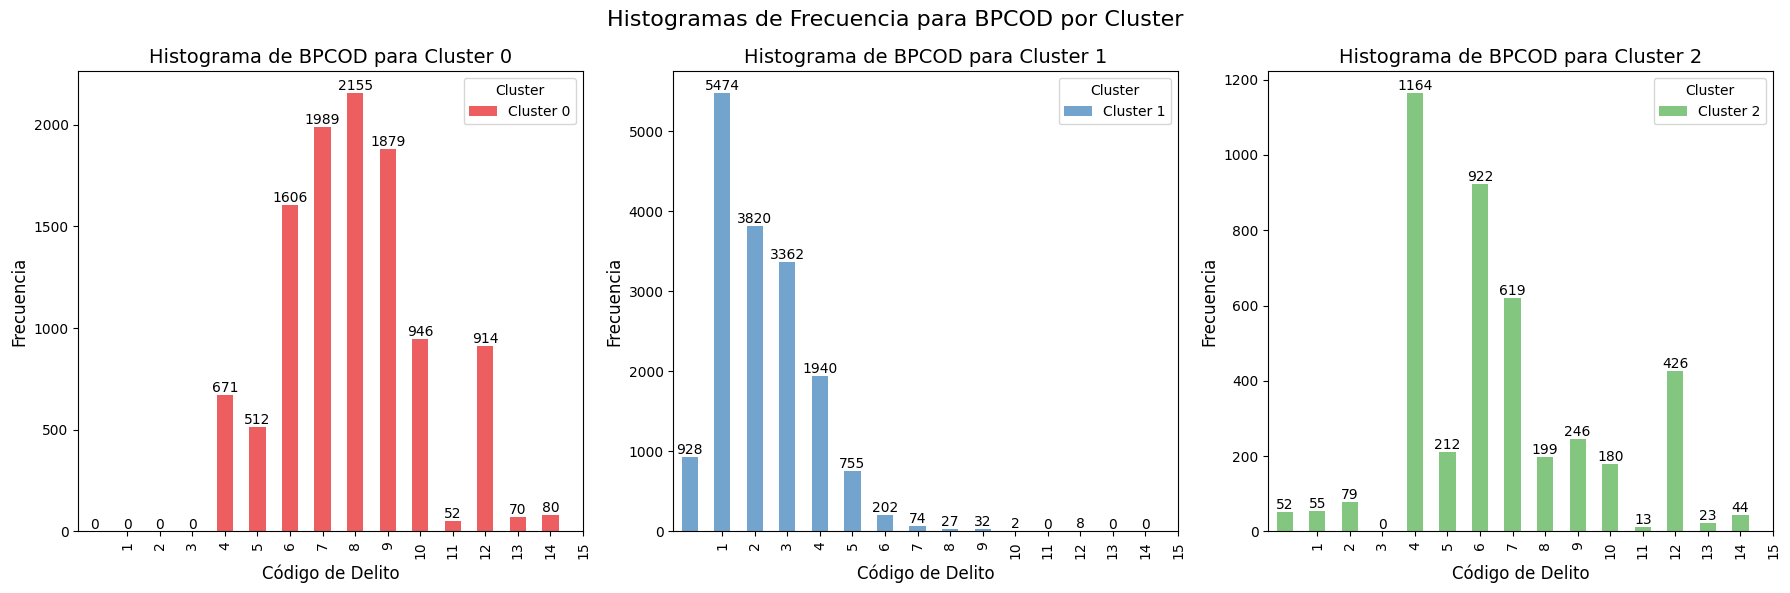

In [ ]:
# Filtrar los clusters
clusters = data_clustered['Cluster'].unique()

# Establecer una paleta de colores con suficientes colores distintos
colors = sns.color_palette("Set1", n_colors=len(clusters))  # Usamos "Set1" para una variedad de colores

# Crear un conjunto de subgráficas para los tres histogramas de BPCOD (uno por cada cluster)
fig, axes = plt.subplots(nrows=1, ncols=len(clusters), figsize=(18, 6))  # 1 fila, 3 columnas
fig.suptitle('Histogramas de Frecuencia para BPCOD por Cluster', fontsize=16)

# Para cada cluster, creamos un histograma para BPCOD
for i, cluster in enumerate(clusters):
    ax = axes[i]  # Subfigura para el cluster
    cluster_data = data_clustered[data_clustered['Cluster'] == cluster]['BPCOD']

    # Contamos la frecuencia de cada valor de BPCOD
    count_data = cluster_data.value_counts().sort_index()  # Ordenar por los valores de BPCOD

    # Crear un arreglo con valores de 1 a 15 (asegurándonos de que todos los valores estén representados)
    all_values = range(1, 16)

    # Si hay valores faltantes en count_data, los añadimos con frecuencia 0
    count_data = count_data.reindex(all_values, fill_value=0)

    # Crear el histograma de barras para BPCOD
    count_data.plot(kind='bar', ax=ax, label=f'Cluster {cluster}', color=colors[i], alpha=0.7)

    # Personalizar el gráfico
    ax.set_title(f'Histograma de BPCOD para Cluster {cluster}', fontsize=14)
    ax.set_xlabel('Código de Delito', fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.legend(title='Cluster')

    # Asegurarse de que los valores de X estén en orden ascendente (del 1 al 15)
    ax.set_xticks(all_values)  # Ajustar el rango de X de 1 a 15
    ax.set_xticklabels(all_values, fontsize=10)  # Etiquetas del eje X

    # Agregar texto explicativo sobre las frecuencias
    for p in ax.patches:  # Recorremos las barras
        ax.annotate(f'{p.get_height()}',  # Agregamos el texto de la frecuencia sobre cada barra
                    (p.get_x() + p.get_width() / 2., p.get_height()),  # Posición del texto
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Ajustar el espacio entre las subgráficas
plt.tight_layout()
plt.show()


In [ ]:
# Seleccionar la característica que deseas analizar
caracteristica = 'BPCOD'  # Solo consideramos la columna 'BPCOD'

# Agrupar los datos por el clúster y contar la frecuencia de cada valor de 'BPCOD'
df_counts = data_clustered.groupby(['Cluster'])[caracteristica].value_counts().unstack(fill_value=0)

# Normalizar los datos (opcional)
df_normalized = df_counts.copy(deep=True)
df_normalized /= df_counts.max()

# Obtener el tamaño del clúster más grande
cluster_sizes = data_clustered.groupby(['Cluster']).size()
cluster_mas_grande = cluster_sizes.max()

# Crear la figura de visualización
fig = go.Figure()

# Crear un gráfico polar para cada clúster
for cluster in df_normalized.index:
    # Calcular los valores radiales y los ángulos (por cada valor de BPCOD)
    radii = df_normalized.loc[cluster, df_normalized.columns].tolist()
    thetas = df_normalized.columns.astype(str).tolist()  # Los valores de BPCOD serán las categorías (eje X)

    # Valores reales para el texto de cada línea
    actual_values = df_counts.loc[cluster, df_counts.columns].tolist()

    # Tamaño del clúster
    cluster_size = cluster_sizes[cluster]

    # Añadir la traza de este clúster en el gráfico polar
    fig.add_trace(
        go.Scatterpolar(
            r=radii + radii[:1],  # Asegurarse de que la línea se cierre al añadir el primer valor al final
            theta=thetas + thetas[:1],  # De igual forma, cerramos el gráfico al añadir el primer ángulo
            mode='lines',
            name=f'Cluster {cluster}',
            text=[f'Frequency: {x}' for x in actual_values + actual_values[:1]],  # Añadir el texto con las frecuencias
            line=dict(width=3),
            opacity=np.max([cluster_size / cluster_mas_grande, 0.6])  # Opacidad en función del tamaño del clúster
        )
    )

# Configuración de la visualización
fig.update_layout(
    title='Distribución de BPCOD (tipo de delito) por Cluster',
    showlegend=True,
    template='plotly_dark',  # Usar un template oscuro para la visualización
    width=800,
    height=600,
    autosize=False
)

# Mostrar el gráfico
fig.show()


# BP1_1: En qué mes del 2023 sucedió el (DELITO)

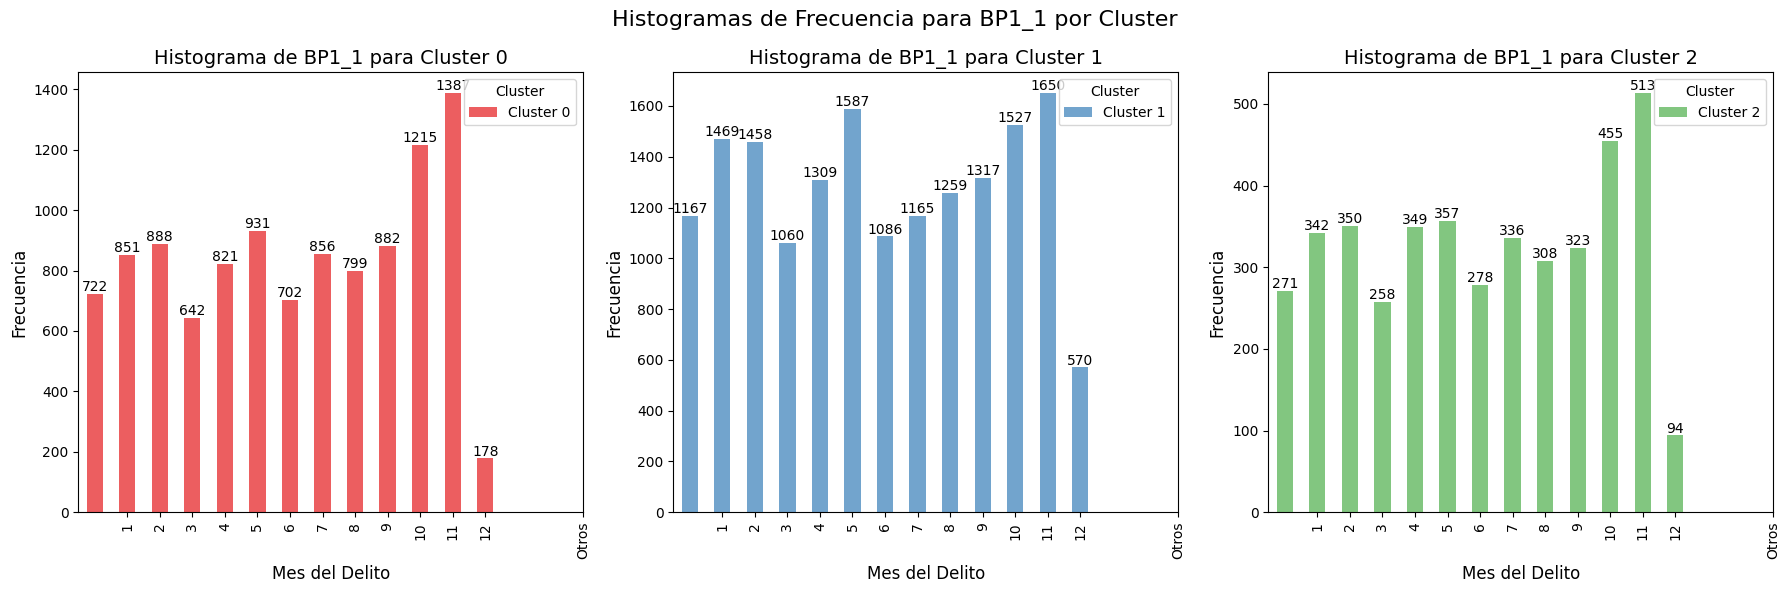

In [ ]:
# Filtrar los clusters
clusters = data_clustered['Cluster'].unique()

# Establecer una paleta de colores con suficientes colores distintos
colors = sns.color_palette("Set1", n_colors=len(clusters))  # Usamos "Set1" para una variedad de colores

# Crear un conjunto de subgráficas para los histogramas de BP1_1 (uno por cada cluster)
fig, axes = plt.subplots(nrows=1, ncols=len(clusters), figsize=(18, 6))  # 1 fila, 3 columnas
fig.suptitle('Histogramas de Frecuencia para BP1_1 por Cluster', fontsize=16)

# Para cada cluster, creamos un histograma para BP1_1
for i, cluster in enumerate(clusters):
    ax = axes[i]  # Subfigura para el cluster
    cluster_data = data_clustered[data_clustered['Cluster'] == cluster]['BP1_1']

    # Contamos la frecuencia de cada valor de BP1_1
    count_data = cluster_data.value_counts().sort_index()  # Ordenar por los valores de BP1_1

    # Filtrar los valores entre 1 y 12
    count_data_filtered = count_data[(count_data.index >= 1) & (count_data.index <= 12)]

    # Agrupar los valores fuera del rango 1-12 en la posición 15
    other_count = count_data[(count_data.index < 1) | (count_data.index > 12)].sum()

    # Insertar el valor "Otro" en la posición 15 con su frecuencia correspondiente
    count_data_filtered[15] = other_count

    # Crear el histograma de barras para BP1_1
    count_data_filtered.plot(kind='bar', ax=ax, label=f'Cluster {cluster}', color=colors[i], alpha=0.7)

    # Personalizar el gráfico
    ax.set_title(f'Histograma de BP1_1 para Cluster {cluster}', fontsize=14)
    ax.set_xlabel('Mes del Delito', fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.legend(title='Cluster')

    # Asegurarse de que los valores de X estén en orden ascendente (del 1 al 12 y luego 15 para "Otros")
    ax.set_xticks(list(range(1, 13)) + [15])  # Ajustar el rango de X de 1 a 12 y luego 15
    ax.set_xticklabels(list(range(1, 13)) + ['Otros'], fontsize=10)  # Etiquetas del eje X

    # Agregar texto explicativo sobre las frecuencias
    for p in ax.patches:  # Recorremos las barras
        ax.annotate(f'{p.get_height()}',  # Agregamos el texto de la frecuencia sobre cada barra
                    (p.get_x() + p.get_width() / 2., p.get_height()),  # Posición del texto
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Ajustar el espacio entre las subgráficas
plt.tight_layout()
plt.show()


In [ ]:
# Seleccionar la característica que deseas analizar
caracteristica = 'BP1_1'  # Ahora analizamos la columna 'BP1_1'

# Agrupar los datos por el clúster y contar la frecuencia de cada valor de 'BP1_1'
df_counts = data_clustered.groupby(['Cluster'])[caracteristica].value_counts().unstack(fill_value=0)

# Normalizar los datos (opcional)
df_normalized = df_counts.copy(deep=True)
#df_normalized /= df_counts.max()

# Obtener el tamaño del clúster más grande
cluster_sizes = data_clustered.groupby(['Cluster']).size()
cluster_mas_grande = cluster_sizes.max()

# Crear la figura de visualización
fig = go.Figure()

# Crear un gráfico polar para cada clúster
for cluster in df_normalized.index:
    # Calcular los valores radiales y los ángulos (por cada valor de BP1_1)
    radii = df_normalized.loc[cluster, df_normalized.columns].tolist()
    thetas = df_normalized.columns.astype(str).tolist()  # Los valores de BP1_1 serán las categorías (eje X)

    # Valores reales para el texto de cada línea
    actual_values = df_counts.loc[cluster, df_counts.columns].tolist()

    # Tamaño del clúster
    cluster_size = cluster_sizes[cluster]

    # Añadir la traza de este clúster en el gráfico polar
    fig.add_trace(
        go.Scatterpolar(
            r=radii + radii[:1],  # Asegurarse de que la línea se cierre al añadir el primer valor al final
            theta=thetas + thetas[:1],  # De igual forma, cerramos el gráfico al añadir el primer ángulo
            mode='lines',
            name=f'Cluster {cluster}',
            text=[f'Frequency: {x}' for x in actual_values + actual_values[:1]],  # Añadir el texto con las frecuencias
            line=dict(width=3),
            opacity=np.max([cluster_size / cluster_mas_grande, 0.6])  # Opacidad en función del tamaño del clúster
        )
    )

# Configuración de la visualización
fig.update_layout(
    title='Distribución de BP1_1 (mes) por Cluster',
    showlegend=True,
    template='plotly_dark',  # Usar un template oscuro para la visualización
    width=800,
    height=600,
    autosize=False
)

# Mostrar el gráfico
fig.show()


# BP1_2C: En qué Estado sucedió el (DELITO)?

In [ ]:
# Seleccionar la característica que deseas analizar
caracteristica = 'BP1_2C'  # Ahora analizamos la columna 'BP1_2C'

# Agrupar los datos por el clúster y contar la frecuencia de cada valor de 'BP1_2C'
df_counts = data_clustered.groupby(['Cluster'])[caracteristica].value_counts().unstack(fill_value=0)

# Normalizar los datos (opcional)
df_normalized = df_counts.copy(deep=True)
#df_normalized /= df_counts.max()

# Obtener el tamaño del clúster más grande
cluster_sizes = data_clustered.groupby(['Cluster']).size()
cluster_mas_grande = cluster_sizes.max()

# Crear la figura de visualización
fig = go.Figure()

# Crear un gráfico polar para cada clúster
for cluster in df_normalized.index:
    # Calcular los valores radiales y los ángulos (por cada valor de BP1_2C)
    radii = df_normalized.loc[cluster, df_normalized.columns].tolist()
    thetas = df_normalized.columns.astype(str).tolist()  # Los valores de BP1_2C serán las categorías (eje X)

    # Valores reales para el texto de cada línea
    actual_values = df_counts.loc[cluster, df_counts.columns].tolist()

    # Tamaño del clúster
    cluster_size = cluster_sizes[cluster]

    # Añadir la traza de este clúster en el gráfico polar
    fig.add_trace(
        go.Scatterpolar(
            r=radii + radii[:1],  # Asegurarse de que la línea se cierre al añadir el primer valor al final
            theta=thetas + thetas[:1],  # De igual forma, cerramos el gráfico al añadir el primer ángulo
            mode='lines',
            name=f'Cluster {cluster}',
            text=[f'Frequency: {x}' for x in actual_values + actual_values[:1]],  # Añadir el texto con las frecuencias
            line=dict(width=3),
            opacity=np.max([cluster_size / cluster_mas_grande, 0.6])  # Opacidad en función del tamaño del clúster
        )
    )

# Configuración de la visualización
fig.update_layout(
    title='Distribución de BP1_2C (estado) por Cluster',
    showlegend=True,
    template='plotly_dark',  # Usar un template oscuro para la visualización
    width=800,
    height=600,
    autosize=False
)

# Mostrar el gráfico
fig.show()


#BP1_4: hora en que se cometió el delito.
* 1: En la mañana (de 6:01 a 12:00 hrs.)
* 2: En la tarde (de 12:01 a 18:00 hrs.)
* 3: En la noche (de 18:01 a 24:00 hrs.)
* 4: En la madrugada (de 00:01 a 6:00 hrs.)
* 9: No sabe / no responde

In [ ]:
# Seleccionar la característica que deseas analizar
caracteristica = 'BP1_4'  # Ahora analizamos la columna 'BP1_4'

# Agrupar los datos por el clúster y contar la frecuencia de cada valor de 'BP1_4'
df_counts = data_clustered.groupby(['Cluster'])[caracteristica].value_counts().unstack(fill_value=0)

# Normalizar los datos (opcional)
df_normalized = df_counts.copy(deep=True)
#df_normalized /= df_counts.max()

# Obtener el tamaño del clúster más grande
cluster_sizes = data_clustered.groupby(['Cluster']).size()
cluster_mas_grande = cluster_sizes.max()

# Crear la figura de visualización
fig = go.Figure()

# Crear un gráfico polar para cada clúster
for cluster in df_normalized.index:
    # Calcular los valores radiales y los ángulos (por cada valor de BP1_4)
    radii = df_normalized.loc[cluster, df_normalized.columns].tolist()
    thetas = df_normalized.columns.astype(str).tolist()  # Los valores de BP1_4 serán las categorías (eje X)

    # Valores reales para el texto de cada línea
    actual_values = df_counts.loc[cluster, df_counts.columns].tolist()

    # Tamaño del clúster
    cluster_size = cluster_sizes[cluster]

    # Añadir la traza de este clúster en el gráfico polar
    fig.add_trace(
        go.Scatterpolar(
            r=radii + radii[:1],  # Asegurarse de que la línea se cierre al añadir el primer valor al final
            theta=thetas + thetas[:1],  # De igual forma, cerramos el gráfico al añadir el primer ángulo
            mode='lines',
            name=f'Cluster {cluster}',
            text=[f'Frequency: {x}' for x in actual_values + actual_values[:1]],  # Añadir el texto con las frecuencias
            line=dict(width=3),
            opacity=np.max([cluster_size / cluster_mas_grande, 0.6])  # Opacidad en función del tamaño del clúster
        )
    )

# Configuración de la visualización
fig.update_layout(
    title='Distribución de BP1_4 (hora) por Cluster',
    showlegend=True,
    template='plotly_dark',  # Usar un template oscuro para la visualización
    width=800,
    height=600,
    autosize=False
)

# Mostrar el gráfico
fig.show()


# BP1_34: ¿En cuánto estima las pérdidas económicas a consecuencia del delito?  

In [ ]:
# Seleccionar la característica que deseas analizar
caracteristica = 'BP1_34'  # Ahora analizamos la columna 'BP1_34'

# Discretizar los datos en 10 intervalos de igual frecuencia (por cuantiles)
data_clustered['BP1_34_quantil'], bins = pd.qcut(data_clustered[caracteristica], 10, labels=False, retbins=True, duplicates='drop')

# Crear etiquetas con los rangos de cada intervalo
interval_labels = [f'{round(bins[i], 2)} - {round(bins[i+1], 2)}' for i in range(len(bins)-1)]

# Agrupar los datos por el clúster y contar la frecuencia de cada valor de 'BP1_34_quantil'
df_counts = data_clustered.groupby(['Cluster'])['BP1_34_quantil'].value_counts().unstack(fill_value=0)

# Normalizar los datos (opcional)
df_normalized = df_counts.copy(deep=True)
#df_normalized /= df_counts.max()

# Obtener el tamaño del clúster más grande
cluster_sizes = data_clustered.groupby(['Cluster']).size()
cluster_mas_grande = cluster_sizes.max()

# Crear la figura de visualización
fig = go.Figure()

# Crear un gráfico polar para cada clúster
for cluster in df_normalized.index:
    # Calcular los valores radiales y los ángulos (por cada valor de BP1_34_quantil)
    radii = df_normalized.loc[cluster, df_normalized.columns].tolist()
    thetas = interval_labels  # Los valores de BP1_34_quantil serán los rangos de los intervalos (eje X)

    # Valores reales para el texto de cada línea
    actual_values = df_counts.loc[cluster, df_counts.columns].tolist()

    # Tamaño del clúster
    cluster_size = cluster_sizes[cluster]

    # Añadir la traza de este clúster en el gráfico polar
    fig.add_trace(
        go.Scatterpolar(
            r=radii + radii[:1],  # Asegurarse de que la línea se cierre al añadir el primer valor al final
            theta=thetas + thetas[:1],  # De igual forma, cerramos el gráfico al añadir el primer ángulo
            mode='lines',
            name=f'Cluster {cluster}',
            text=[f'Frequency: {x}' for x in actual_values + actual_values[:1]],  # Añadir el texto con las frecuencias
            line=dict(width=3),
            opacity=np.max([cluster_size / cluster_mas_grande, 0.6])  # Opacidad en función del tamaño del clúster
        )
    )

# Configuración de la visualización
fig.update_layout(
    title='Distribución de BP1_34 (pérdidas económicas) por Cluster (Con 10 Intervalos)',
    showlegend=True,
    template='plotly_dark',  # Usar un template oscuro para la visualización
    width=800,
    height=600,
    autosize=False
)

# Mostrar el gráfico
fig.show()









#Ahora un mapa

In [ ]:
clave_municipio = pd.read_excel(os.path.join(DATA_DIR, "Clave_municipio.xlsx"))
clave_municipio.head()

In [ ]:
clave_municipio = pd.read_excel('/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos en Mexico/Clave_municipio.xlsx')
clave_municipio.head()

,Clave Entidad,Nombre Entidad,Clave municipio,Nombre municipio
0,1,Aguascalientes,1,Aguascalientes
1,1,Aguascalientes,5,Jesús María
2,2,Baja California,4,Tijuana
3,3,Baja California,3,La Paz
4,4,Campeche,2,Campeche


In [ ]:
# Hacer el merge entre data_clustered y clave_municipio
merged_data = data_clustered.merge(
    clave_municipio[['Clave Entidad', 'Clave municipio', 'Nombre municipio', 'Nombre Entidad']],  # Seleccionar las columnas necesarias
    left_on=['BP1_2C', 'BP1_3C'],  # Las claves de entidad y municipio en data_clustered
    right_on=['Clave Entidad', 'Clave municipio'],  # Las claves de entidad y municipio en clave_municipio
    how='left'  # Unir con todos los registros de data_clustered (izquierda)
)

# Verificar que se haya agregado la columna correctamente
merged_data.head()

,BPCOD,BP1_1,BP1_2C,BP1_3C,BP1_4,BP1_5,BP1_34,Cluster,BP1_34_quantil,Clave Entidad,Clave municipio,Nombre municipio,Nombre Entidad
0,7,1,1,1,3,1,10000.0,0,6,1.0,1.0,Aguascalientes,Aguascalientes
1,2,9,1,1,4,1,20000.0,1,6,1.0,1.0,Aguascalientes,Aguascalientes
2,7,6,1,1,2,5,150.0,2,0,1.0,1.0,Aguascalientes,Aguascalientes
3,5,11,1,1,2,1,3000.0,1,3,1.0,1.0,Aguascalientes,Aguascalientes
4,3,10,1,1,3,2,1500.0,1,2,1.0,1.0,Aguascalientes,Aguascalientes


#Veamos los esultado en un mapa

In [ ]:
# Inicializar el geolocalizador
geolocator = Nominatim(user_agent="mapa_municipios_clusters", timeout=10)

# Crear el mapa centrado en México
mapa = folium.Map(location=[23.6345, -102.5528], zoom_start=5)

# Función para geolocalizar con reintentos en caso de timeout
def geolocalizar_con_reintento(municipio, estado, geolocator, intentos=3, tiempo_espera=2):
    for intento in range(intentos):
        try:
            location = geolocator.geocode(f"{municipio}, {estado}, México")
            if location:
                return location.latitude, location.longitude
            else:
                return None, None  # Si no se encuentra la ubicación
        except GeocoderTimedOut:
            print(f"Timeout al geolocalizar {municipio}, {estado}. Reintentando ({intento+1}/{intentos})...")
            time.sleep(tiempo_espera)
        except Exception as e:
            print(f"Error al geolocalizar {municipio}, {estado}: {e}")
            return None, None
    return None, None  # Si no se pudo obtener la geolocalización después de varios intentos

# Contar la cantidad de veces que cada municipio aparece en cada cluster
municipios_cluster_counts = merged_data.groupby(['Nombre municipio', 'Nombre Entidad', 'Cluster']).size().reset_index(name='Count')

# Extraer municipios y estados únicos
municipios = municipios_cluster_counts[['Nombre municipio', 'Nombre Entidad']].drop_duplicates()

# Función para asignar un color según el cluster
def obtener_color_cluster(cluster):
    if cluster == 0:
        return "blue"
    elif cluster == 1:
        return "green"
    elif cluster == 2:
        return "orange"
    elif cluster == 3:
        return "red"
    else:
        return "gray"  # Default color for others

# Desplazamientos controlados para los clusters
def obtener_desplazamiento_cluster(cluster):
    if cluster == 0:
        return 0, 0  # Sin desplazamiento
    elif cluster == 1:
        return 0.01, 0  # Desplazamiento hacia arriba
    elif cluster == 2:
        return 0, 0.01  # Desplazamiento hacia la derecha
    elif cluster == 3:
        return 0, -0.01  # Desplazamiento hacia la izquierda
    else:
        return 0, 0  # Sin desplazamiento

# Usar la función con reintentos para obtener las coordenadas y agregar círculos
for _, row in municipios.iterrows():
    municipio = row['Nombre municipio']
    estado = row['Nombre Entidad']

    # Contamos cuántas veces aparece este municipio en cada cluster
    cluster_counts = municipios_cluster_counts[municipios_cluster_counts['Nombre municipio'] == municipio]

    # Geolocalizar el municipio
    lat, lon = geolocalizar_con_reintento(municipio, estado, geolocator)

    if lat is not None and lon is not None:
        # Para cada municipio, agregar un círculo con un tamaño proporcional a la cantidad de eventos
        for idx, cluster_row in cluster_counts.iterrows():
            count = cluster_row['Count']
            cluster = cluster_row['Cluster']

            # Obtener el desplazamiento para este cluster
            lat_offset, lon_offset = obtener_desplazamiento_cluster(cluster)

            # Coordenadas desplazadas
            lat_disp = lat + lat_offset
            lon_disp = lon + lon_offset

            # Asignar un color y tamaño según el cluster y la frecuencia
            color = obtener_color_cluster(cluster)
            #radius = count * 3  # El tamaño del círculo depende de la frecuencia (puedes ajustar el multiplicador)

            # Crear el marcador con el círculo de tamaño proporcional
            folium.CircleMarker(
                location=[lat_disp, lon_disp],
                radius=min(count / 3, 25),  # Limitar el tamaño máximo del círculo
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                popup=f"Municipio: {municipio}<br>Estado: {estado}<br>Cluster: {cluster}<br>Frecuencia: {count}"
            ).add_to(mapa)
    else:
        print(f"Coordenadas no válidas para {municipio}, {estado}")

# Mostrar el mapa
mapa


Coordenadas no válidas para Almoloya de Juárez, México Poniente
Coordenadas no válidas para Lerma, México Poniente
Coordenadas no válidas para Metepec, México Poniente
Coordenadas no válidas para San Mateo Atenco, México Poniente
